In [1]:
%load_ext autoreload
%autoreload 2

import sys
from pathlib import Path
import pandas as pd

# Ensure the notebook can find the /src directory
root_path = Path.cwd().parent
if str(root_path) not in sys.path:
    sys.path.append(str(root_path))

In [2]:
from src.data_loader import VesselDataLoader
from src.regime_classifier import VesselRegimeClassifier
from src.visualizer import VesselVisualizer

In [3]:
# Path to your raw telemetry
raw_data_file1 = root_path / "data" / "raw" / "Rotherhithe_voy_179.csv"

# Instantiate
loader1 = VesselDataLoader(raw_data_file1)

# The new load_and_clean method now stops before the definitions footer
df = loader1.load_and_clean()

Successfully loaded, cleaned, and processed 2880 telemetry rows.


In [19]:
priors_file1 = root_path / "data" / "config" / "ELA_PRIORS.csv"
priors1 = pd.read_csv(priors_file1)
classifier1 = VesselRegimeClassifier(priors1)

# Extract only the necessary features and predict
features = df[['AE_POWER(kW)', 'NUM_GENERATORS']].dropna()
df.loc[features.index, 'RAW_REGIME'] = classifier1.fit_predict_raw(features)

# Map labels to human-readable strings
label_map = {i: regime for i, regime in enumerate(priors1['REGIME'])}
df['REGIME_NAME'] = classifier1.apply_temporal_filter(df['RAW_REGIME'], window_size=72).map(label_map)
df['IS_TRANSIENT'] = classifier1.extract_transients(df['RAW_REGIME'], df['REGIME_NAME'].map({v: k for k, v in label_map.items()}))

classifier1.generate_validation_report(df)




MARINER REGIME VALIDATION REPORT
Comparison: STATUS (Raw) vs. REGIME_NAME (Physical)
------------------------------
REGIME_NAME  LOADING  SEA GOING  TANK CLEANING  TANK HEATING  TOTAL
STATUS                                                             
ballast          215        220              0             0    435
discharging        8          0             88           266    362
idle             242        861             82             1   1186
laden             19        621              0             0    640
loading            0        257              0             0    257
TOTAL            484       1959            170           267   2880

--- Critical Physical Insights ---
Raw Status 'IDLE' is 72.6% 'SEA GOING' physically.
Raw Status 'BALLAST' is 50.6% 'SEA GOING' physically.
Raw Status 'LADEN' is 97.0% 'SEA GOING' physically.
Raw Status 'DISCHARGING' is 73.5% 'TANK HEATING' physically.


REGIME_NAME,LOADING,SEA GOING,TANK CLEANING,TANK HEATING,TOTAL
STATUS,,,,,
ballast,215,220,0,0,435
discharging,8,0,88,266,362
idle,242,861,82,1,1186
laden,19,621,0,0,640
loading,0,257,0,0,257
TOTAL,484,1959,170,267,2880


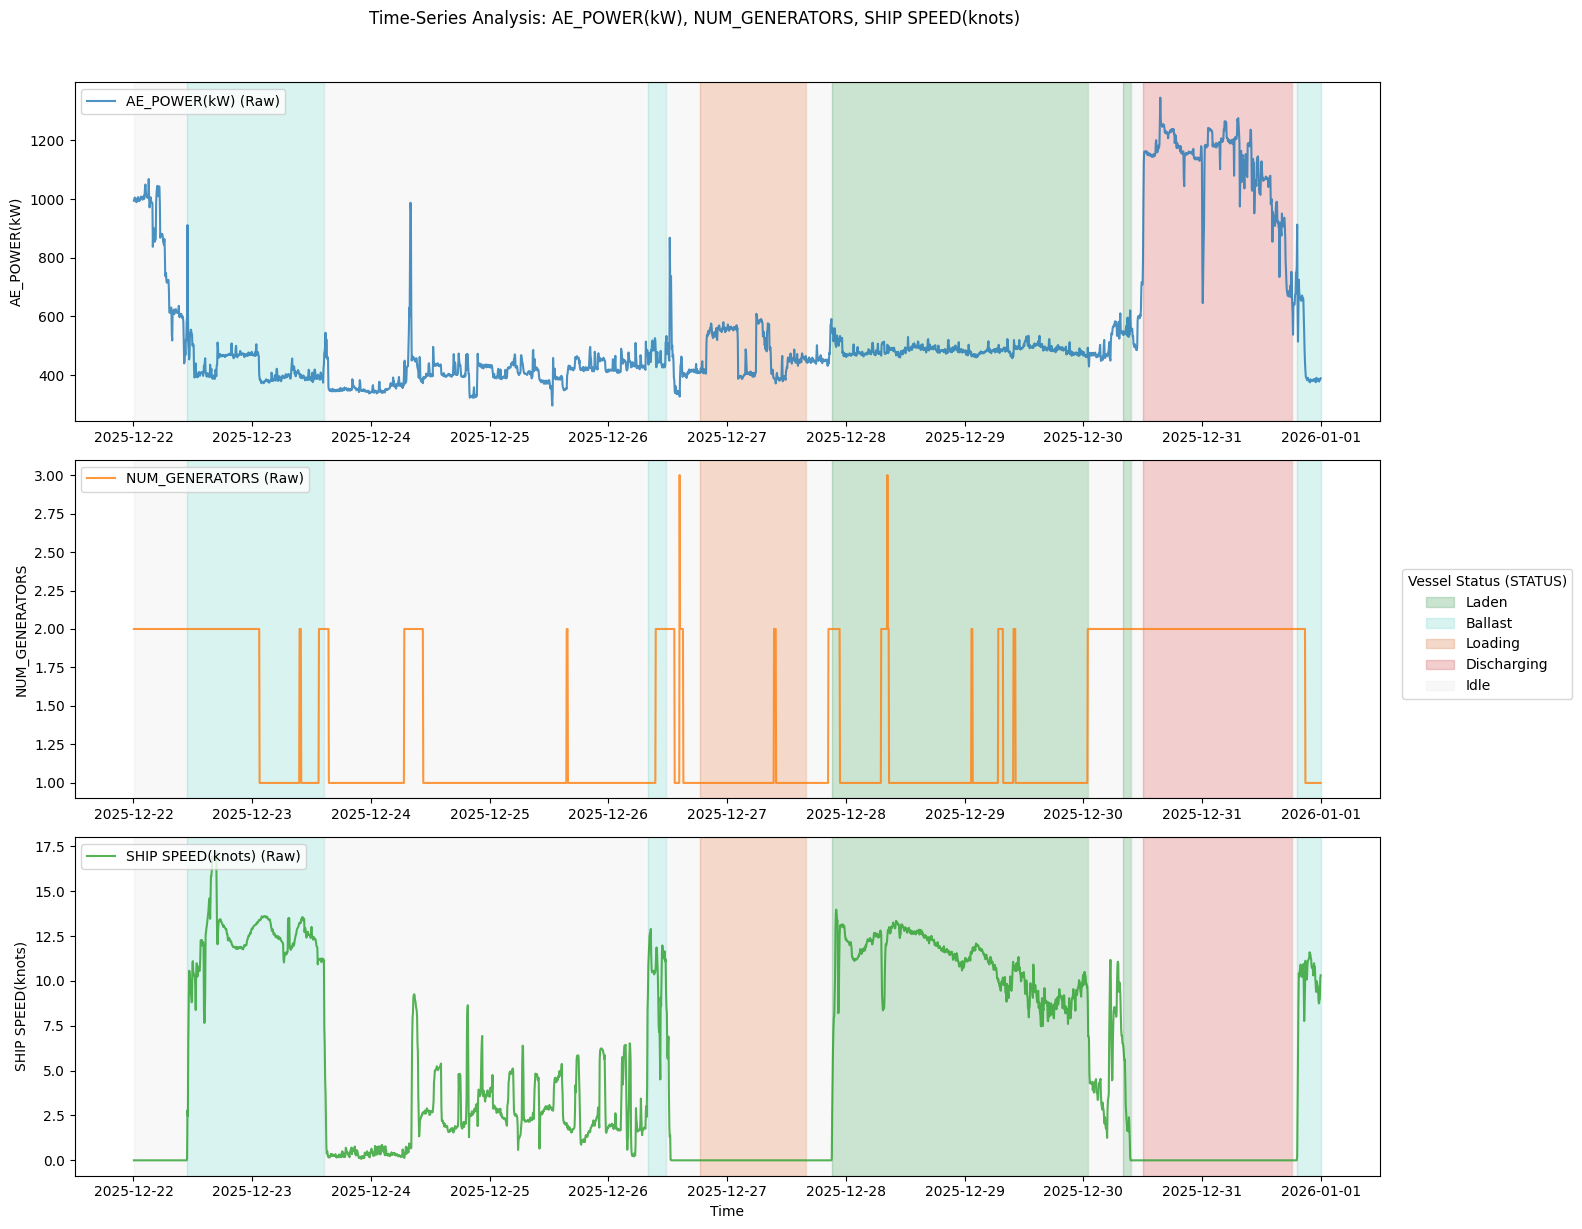

In [24]:
plotter = VesselVisualizer(df)

# Plot using the ML-derived Regimes
fig, ax = plotter.plot_series(columns=['AE_POWER(kW)', 'NUM_GENERATORS', 'SHIP SPEED(knots)'],subplots=True, status_col='STATUS')

# Map using the ML-derived Regimes
vessel_map = plotter.plot_trajectory_folium(status_col='REGIME_NAME')



In [25]:
# Map using the ML-derived Regimes
vessel_map1 = plotter.plot_trajectory_folium(status_col='STATUS')
vessel_map1

In [27]:
# Path to your raw telemetry
raw_data_file2 = root_path / "data" / "raw" / "Wembley_voy_236.csv"

# Instantiate
loader2 = VesselDataLoader(raw_data_file2)

# The new load_and_clean method now stops before the definitions footer
df = loader2.load_and_clean()

Successfully loaded, cleaned, and processed 3168 telemetry rows.


In [28]:
priors_file2 = root_path / "data" / "config" / "ELA_PRIORS.csv"
priors2 = pd.read_csv(priors_file2)
classifier2 = VesselRegimeClassifier(priors2)

# Extract only the necessary features and predict
features = df[['AE_POWER(kW)', 'NUM_GENERATORS']].dropna()
df.loc[features.index, 'RAW_REGIME'] = classifier2.fit_predict_raw(features)

# Map labels to human-readable strings
label_map = {i: regime for i, regime in enumerate(priors2['REGIME'])}
df['REGIME_NAME'] = classifier2.apply_temporal_filter(df['RAW_REGIME'], window_size=72).map(label_map)
df['IS_TRANSIENT'] = classifier2.extract_transients(df['RAW_REGIME'], df['REGIME_NAME'].map({v: k for k, v in label_map.items()}))

classifier2.generate_validation_report(df)




MARINER REGIME VALIDATION REPORT
Comparison: STATUS (Raw) vs. REGIME_NAME (Physical)
------------------------------
REGIME_NAME  AT HARBOUR  GAS FREEING  LOADING  SEA GOING  TANK HEATING  TOTAL
STATUS                                                                       
ballast             171            0       82         29             0    282
discharging           8            0        0          0           404    412
idle                605           26      159        181           130   1101
laden               952            0        0        367             0   1319
loading              40            0       14          0             0     54
TOTAL              1776           26      255        577           534   3168

--- Critical Physical Insights ---
Raw Status 'IDLE' is 55.0% 'AT HARBOUR' physically.
Raw Status 'BALLAST' is 60.6% 'AT HARBOUR' physically.
Raw Status 'LOADING' is 74.1% 'AT HARBOUR' physically.
Raw Status 'LADEN' is 72.2% 'AT HARBOUR' physically.
Raw Stat

REGIME_NAME,AT HARBOUR,GAS FREEING,LOADING,SEA GOING,TANK HEATING,TOTAL
STATUS,,,,,,
ballast,171,0,82,29,0,282
discharging,8,0,0,0,404,412
idle,605,26,159,181,130,1101
laden,952,0,0,367,0,1319
loading,40,0,14,0,0,54
TOTAL,1776,26,255,577,534,3168


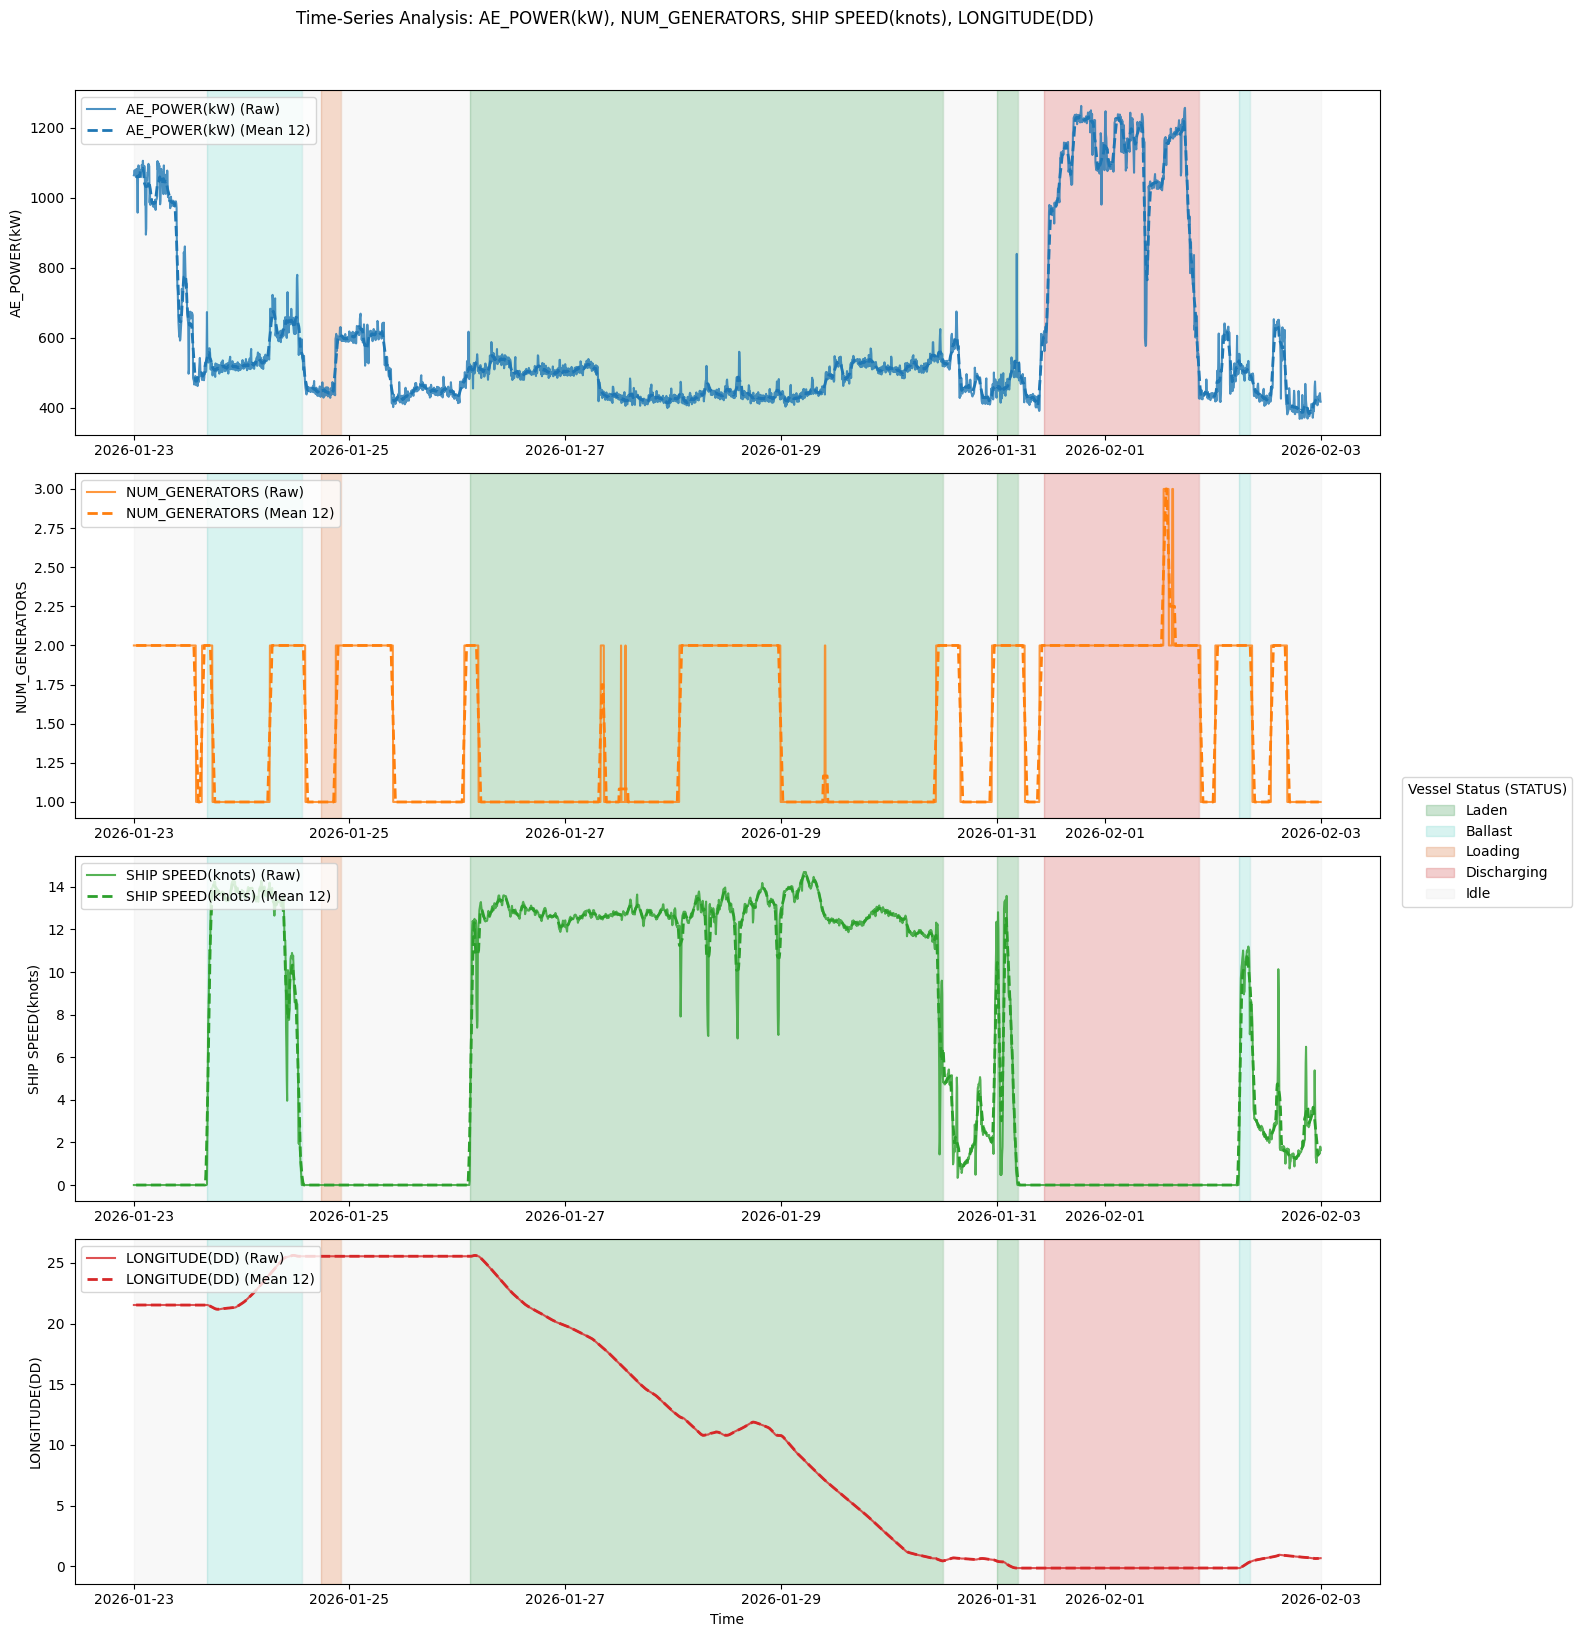

In [32]:
plotter = VesselVisualizer(df)

# Plot using the ML-derived Regimes
fig, ax = plotter.plot_series(columns=['AE_POWER(kW)', 'NUM_GENERATORS', 'SHIP SPEED(knots)','LONGITUDE(DD)'],subplots=True, status_col='STATUS', rolling_window=12)

In [31]:
# Map using the ML-derived Regimes
vessel_map1 = plotter.plot_trajectory_folium(status_col='STATUS')
vessel_map1